In [257]:
import tensorflow as ts
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [258]:
df = pd.read_csv("http://storage.googleapis.com/download.tensorflow.org/data/heart.csv")

In [259]:
df.shape

(303, 14)

In [260]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,fixed,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,normal,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,reversible,0
3,37,1,3,130,250,0,0,187,0,3.5,3,0,normal,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,normal,0


In [261]:
# check if 1s and 0s are balanced

df.target.value_counts(normalize=True, dropna=False)

target
0    0.726073
1    0.273927
Name: proportion, dtype: float64

# Preprocessing

In [262]:
categorical_vars = ["sex", "cp", "fbs", "restecg", "exang", "ca", "thal"]
numerics = ["age", "trestbps", "chol", "thalach", "oldpeak", "slope"]

In [263]:
df = pd.get_dummies(df, columns = categorical_vars) # convert categorical features to numerics

In [264]:
df.head()

,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,...,exang_1,ca_0,ca_1,ca_2,ca_3,thal_1,thal_2,thal_fixed,thal_normal,thal_reversible
0,63,145,233,150,2.3,3,0,False,True,False,...,False,True,False,False,False,False,False,True,False,False
1,67,160,286,108,1.5,2,1,False,True,False,...,True,False,False,False,True,False,False,False,True,False
2,67,120,229,129,2.6,2,0,False,True,False,...,True,False,False,True,False,False,False,False,False,True
3,37,130,250,187,3.5,3,0,False,True,False,...,False,True,False,False,False,False,False,False,True,False
4,41,130,204,172,1.4,1,0,True,False,False,...,False,True,False,False,False,False,False,False,True,False


In [265]:
test_df = df.sample(frac=0.2, random_state=42)
train_df = df.drop(test_df.index)

In [266]:
train_df.shape

(242, 30)

In [267]:
test_df.shape

(61, 30)

In [268]:
means = train_df[numerics].mean()
sd = train_df[numerics].std()

In [269]:
means

age          54.268595
trestbps    131.995868
chol        246.512397
thalach     149.805785
oldpeak       1.032645
slope         1.590909
dtype: float64

In [270]:
# standardize numerics 

train_df[numerics] = (train_df[numerics] - means) / sd
test_df[numerics] = (test_df[numerics] - means) / sd

In [271]:
train_df.head()

,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,...,exang_1,ca_0,ca_1,ca_2,ca_3,thal_1,thal_2,thal_fixed,thal_normal,thal_reversible
0,0.963746,0.721939,-0.278690,0.008396,1.083461,2.226814,0,False,True,False,...,False,True,False,False,False,False,False,True,False,False
1,1.405254,1.554681,0.814423,-1.807247,0.399542,0.646494,1,False,True,False,...,True,False,False,False,True,False,False,False,True,False
2,1.405254,-0.665964,-0.361189,-0.899426,1.339930,0.646494,0,False,True,False,...,True,False,False,True,False,False,False,False,False,True
3,-1.906055,-0.110803,0.071931,1.607891,2.109339,2.226814,0,False,True,False,...,False,True,False,False,False,False,False,False,True,False
4,-1.464547,-0.110803,-0.876809,0.959447,0.314052,-0.933825,0,True,False,False,...,False,True,False,False,False,False,False,False,True,False


In [272]:
# convert to np arrays in order to be processable by the NN

train = train_df.to_numpy().astype("float32")
test = test_df.to_numpy().astype("float32")

In [273]:
train_X = np.delete(train, 6, axis=1)
test_X = np.delete(test, 6, axis=1)

In [274]:
train_X.shape

(242, 29)

In [275]:
test_X.shape

(61, 29)

In [276]:
train_y = train[:, 6]
test_y = test[:, 6]

In [277]:
train_y.shape, test_y.shape

((242,), (61,))

# Build the model

In [278]:
num_columns = train_X.shape[1]

# define input layer

input = keras.Input(shape=(num_columns, )) # note the comma "," because it needs input in tuple format 

# feed input vector to hidden layer
# optional: give names to each layer to keep track

h = keras.layers.Dense(16, activation="relu", name="Hidden")(input)

# feed the output of the hidden layer to output layer

output = keras.layers.Dense(1, activation="sigmoid", name="Output")(h)

# tell Keras that this (input, output) pair is the model

model = keras.Model(input, output)

In [279]:
model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 29)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden (Dense)                  │ (None, 16)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 497 (1.94 KB)

 Trainable params: 497 (1.94 KB)

 Non-trainable params: 0 (0.00 B)

In [280]:
(29 + 1) * 16 + (16 + 1) * 1 # Calculation of the parameters by hand (double-checking)

# General rule: (inputs + 1) * neurons FOR DENSE LAYERS

497

In [281]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train the model

In [282]:
# train_X = train_X.astype("float32")
# train_y = train_y.astype("float32")

In [283]:
history = model.fit(
    train_X,
    train_y,
    epochs=300,
    batch_size=32,
    verbose=1,
    validation_split=0.2
)

Epoch 1/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5544 - loss: 0.7839 - val_accuracy: 0.5510 - val_loss: 0.7531
Epoch 2/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5907 - loss: 0.7460 - val_accuracy: 0.6327 - val_loss: 0.7295
Epoch 3/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6528 - loss: 0.7158 - val_accuracy: 0.6327 - val_loss: 0.7115
Epoch 4/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6943 - loss: 0.6894 - val_accuracy: 0.6531 - val_loss: 0.6946
Epoch 5/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7098 - loss: 0.6649 - val_accuracy: 0.6531 - val_loss: 0.6793
Epoch 6/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7202 - loss: 0.6447 - val_accuracy: 0.6531 - val_loss: 0.6643
Epoch 7/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7254 - loss: 0.6255 - val_accuracy: 0.6531 - val_loss: 0.6500
Epoch 8/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7254 - loss: 0.6064 - val_accuracy: 0.6531 - val_loss: 0.6375

In [284]:
history_dict = history.history

history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

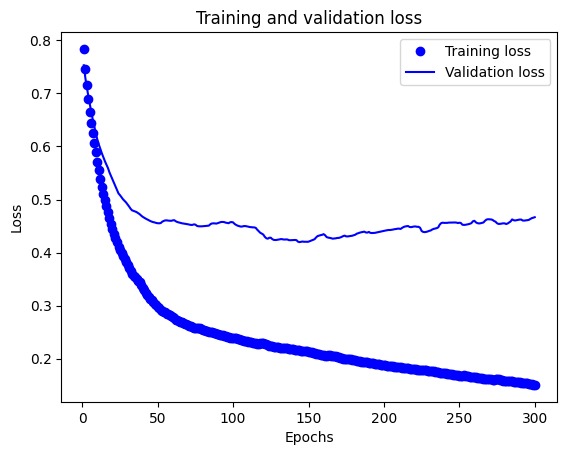

In [285]:
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "bo", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

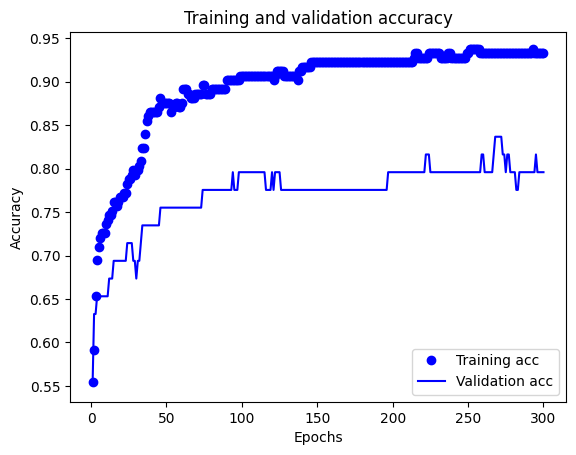

In [286]:
plt.clf()
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
plt.plot(epochs, acc, "bo", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Evaluate the model

In [287]:
model.evaluate(test_X, test_y)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8361 - loss: 0.4225


[0.42253339290618896, 0.8360655903816223]